<div style="background:#142d4e;color:#ffffff;padding:26px 30px;border-radius:14px;border-left:8px solid #24b8a8;">
<p style="margin:0;letter-spacing:2px;font-size:12px;">IASEG · APRENDIZADO DE MÁQUINA · AULA 2</p>
<h1 style="color:#ffffff;margin:10px 0;">Energia: dos dados às perguntas</h1>
<p style="margin:0;color:#d9edf5;">Caderno de atividades · análise de dados · respostas do grupo</p>
</div>

**Objetivo:** propor pelo menos um problema supervisionado e um não supervisionado, indicando a saída do modelo e os dados de entrada.

| Etapa | O que fazer |
|:--|:--|
| 1 · Entender | Ler a situação e os dados disponíveis. |
| 2–4 · Explorar | Executar as células, examinar tabelas e gráficos. |
| 5 · Responder | Preencher os campos de texto e experimentar seu próprio código. |
| 6 · Experimentar | Executar e adaptar duas demonstrações de modelos. |
| 7 · Revisar | Conferir as respostas e salvar o notebook. |

> **Dados fictícios.** As cinco tabelas do Markdown original foram preservadas. Elas contêm apenas 5 clientes e leituras de janeiro e fevereiro de 2024; não representam os 2 milhões de clientes nem os 5 anos de histórico do cenário.

## Como preencher e executar

1. Abra este arquivo no Jupyter, VS Code com suporte a notebooks ou Google Colab e selecione um kernel **Python 3**.
2. Execute as células de cima para baixo com **Shift + Enter**, ou use **Executar tudo / Run All**.
3. Dê dois cliques nas células de texto para substituir os trechos entre colchetes pelas respostas. Use **Shift + Enter** para voltar à visualização formatada.
4. Edite as células de código nos espaços indicados. Se alterar os dados, execute novamente as células seguintes.
5. Para marcar um item, troque `[ ]` por `[x]` no texto. Salve o arquivo ao terminar.

**No VS Code:** selecione o Python da pasta `.venv` do projeto. No terminal, a partir da raiz do projeto, você pode abrir o Jupyter com `.\.venv\Scripts\python.exe -m notebook aula2/exercicio.ipynb`.

As respostas escritas permanecem em branco. Os resultados salvos são exemplos de execução.

[Instruções gerais](exercicio-instrucoes.md) · [Versão em Markdown](exercicio.md)

## Identificação do grupo

- **Grupo:** [Digite o número ou nome do grupo]
- **Integrantes:** [Digite os nomes]
- **Data:** [Digite a data]

## 1 · Situação e dados disponíveis

Uma distribuidora de energia atende cerca de 2 milhões de clientes. A diretoria quer usar os dados que já possui para operar melhor: reduzir perdas, planejar a manutenção da rede e entender como as pessoas consomem.

## Dados disponíveis

- Leituras mensais de consumo por cliente nos últimos 5 anos. Quando o medidor não pode ser lido — portão fechado, cachorro ou morador ausente —, o sistema registra uma estimativa calculada a partir dos meses anteriores.
- Cadastro: tipo de ligação (residencial, comercial ou industrial), bairro e data de instalação.
- Histórico de interrupções de fornecimento por região.
- Registros de inspeção técnica, feitos quando houve suspeita de irregularidade.
- Chamados abertos na central de atendimento.

## 2 · Preparar o ambiente

Usaremos `pandas` para as tabelas, `matplotlib` para os gráficos e `scikit-learn` para as demonstrações de modelos.

Se aparecer `ModuleNotFoundError`, retire o `#` da linha abaixo, execute-a e reinicie o kernel antes de continuar. A instalação requer internet; as análises usam apenas os dados definidos neste notebook.

In [ ]:
# Execute somente se precisar instalar as dependências neste kernel.
# %pip install pandas numpy matplotlib scikit-learn jinja2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML
from html import escape

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 20)

CORES = {"azul": "#245784", "verde": "#138f86", "ambar": "#cf8c24",
         "roxo": "#7757a6", "texto": "#26374c"}

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": CORES["texto"],
    "text.color": CORES["texto"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "grid.alpha": 0.18,
})

def mostrar_tabela(tabela, titulo, formatos=None):
    """Exibe uma tabela legível, sem alterar os dados originais."""
    display(HTML(f"<h4 style='color:#245784;margin:20px 0 8px'>{escape(titulo)}</h4>"))
    estilo = (
        tabela.style
        .hide(axis="index")
        .format(formatos or {}, na_rep="—", escape="html")
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#142d4e"),
                                        ("color", "#ffffff"), ("text-align", "left"),
                                        ("padding", "9px 12px")]},
            {"selector": "td", "props": [("padding", "8px 12px"),
                                        ("border-bottom", "1px solid #dce4ed"),
                                        ("color", "#26374c")]},
            {"selector": "tbody tr:nth-child(odd)", "props": [("background-color", "#f1f6fa")]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#ffffff")]},
            {"selector": "table", "props": [("border-collapse", "collapse"),
                                           ("font-size", "13px")]},
        ])
    )
    display(estilo)

print("Ambiente pronto. Execute a próxima célula para criar as cinco tabelas.")

Ambiente pronto. Execute a próxima célula para criar as cinco tabelas.


## 3 · Criar e visualizar as tabelas

Execute a célula abaixo para criar `clientes`, `leituras`, `interrupcoes`, `inspecoes` e `chamados`, com os mesmos registros do arquivo original.

**Como relacionar as tabelas:** `cliente_id` conecta cadastro, leituras, inspeções e chamados. As interrupções são registradas por região; nesta amostra, os nomes de `regiao` correspondem aos bairros. Qualquer análise conjunta também precisa considerar as datas.

> Uma leitura estimada foi preenchida pelo sistema e não corresponde a uma medição real. Os registros de inspeção vêm de casos suspeitos; seus resultados não são uma amostra aleatória de todos os clientes.

In [ ]:
import pandas as pd

# Cadastro dos clientes
clientes = pd.DataFrame({
    "cliente_id": [1001, 1002, 1003, 1004, 1005],
    "tipo_ligacao": ["residencial", "comercial", "industrial", "residencial", "comercial"],
    "bairro": ["Centro", "Jardins", "Distrito Industrial", "Centro", "Jardins"],
    "data_instalacao": pd.to_datetime([
        "2018-03-12", "2020-07-05", "2016-11-20", "2022-01-15", "2019-09-30"
    ])
})

# Leituras mensais; medicao_estimada indica que o valor foi calculado pelo sistema
leituras = pd.DataFrame({
    "cliente_id": [1001, 1001, 1002, 1002, 1003, 1003, 1004, 1005],
    "mes": pd.to_datetime([
        "2024-01-01", "2024-02-01", "2024-01-01", "2024-02-01",
        "2024-01-01", "2024-02-01", "2024-02-01", "2024-02-01"
    ]),
    "consumo_kwh": [210, 225, 980, 1020, 5400, 5100, 180, 760],
    "medicao_estimada": [False, True, False, False, True, False, False, True]
})

# Interrupções registradas por região
interrupcoes = pd.DataFrame({
    "regiao": ["Centro", "Jardins", "Distrito Industrial", "Centro", "Jardins"],
    "data": pd.to_datetime([
        "2024-01-08", "2024-01-12", "2024-01-15", "2024-02-03", "2024-02-10"
    ]),
    "duracao_minutos": [35, 120, 45, 20, 90],
    "clientes_afetados": [320, 180, 75, 140, 210]
})

# Inspeções técnicas após suspeita de irregularidade
inspecoes = pd.DataFrame({
    "inspecao_id": [1, 2, 3, 4, 5],
    "cliente_id": [1001, 1002, 1003, 1004, 1005],
    "data_inspecao": pd.to_datetime([
        "2024-02-05", "2024-02-06", "2024-02-07", "2024-02-08", "2024-02-09"
    ]),
    "irregularidade_confirmada": [False, False, True, False, True]
})

# Chamados registrados na central de atendimento
chamados = pd.DataFrame({
    "chamado_id": [501, 502, 503, 504, 505],
    "cliente_id": [1001, 1002, 1003, 1004, 1005],
    "data_abertura": pd.to_datetime([
        "2024-01-10", "2024-01-18", "2024-01-20", "2024-02-02", "2024-02-11"
    ]),
    "categoria": ["leitura", "interrupcao", "leitura", "interrupcao", "faturamento"],
    "resolvido": [True, True, False, True, False]
})

print("Tabelas criadas com os dados fictícios do Markdown original.")

Tabelas criadas com os dados fictícios do Markdown original.


In [ ]:
resumo_bases = pd.DataFrame({
    "Tabela": ["clientes", "leituras", "interrupcoes", "inspecoes", "chamados"],
    "Linhas": [len(clientes), len(leituras), len(interrupcoes), len(inspecoes), len(chamados)],
    "Uma linha representa": [
        "Um cliente", "Uma leitura mensal", "Uma interrupção por região",
        "Uma inspeção técnica", "Um chamado de atendimento"
    ],
})
mostrar_tabela(resumo_bases, "Visão geral da amostra")

mostrar_tabela(clientes, "Cadastro dos clientes",
               {"data_instalacao": lambda valor: valor.strftime("%d/%m/%Y")})
mostrar_tabela(leituras, "Leituras mensais",
               {"mes": lambda valor: valor.strftime("%m/%Y"),
                "consumo_kwh": "{:,.0f}",
                "medicao_estimada": lambda valor: "Estimada" if valor else "Medida"})
mostrar_tabela(interrupcoes, "Interrupções",
               {"data": lambda valor: valor.strftime("%d/%m/%Y")})
mostrar_tabela(inspecoes, "Inspeções",
               {"data_inspecao": lambda valor: valor.strftime("%d/%m/%Y"),
                "irregularidade_confirmada": lambda valor: "Sim" if valor else "Não"})
mostrar_tabela(chamados, "Chamados",
               {"data_abertura": lambda valor: valor.strftime("%d/%m/%Y"),
                "resolvido": lambda valor: "Sim" if valor else "Não"})

Tabela,Linhas,Uma linha representa
clientes,5,Um cliente
leituras,8,Uma leitura mensal
interrupcoes,5,Uma interrupção por região
inspecoes,5,Uma inspeção técnica
chamados,5,Um chamado de atendimento


cliente_id,tipo_ligacao,bairro,data_instalacao
1001,residencial,Centro,12/03/2018
1002,comercial,Jardins,05/07/2020
1003,industrial,Distrito Industrial,20/11/2016
1004,residencial,Centro,15/01/2022
1005,comercial,Jardins,30/09/2019


cliente_id,mes,consumo_kwh,medicao_estimada
1001,01/2024,210,Medida
1001,02/2024,225,Estimada
1002,01/2024,980,Medida
1002,02/2024,"1,020",Medida
1003,01/2024,"5,400",Estimada
1003,02/2024,"5,100",Medida
1004,02/2024,180,Medida
1005,02/2024,760,Estimada


regiao,data,duracao_minutos,clientes_afetados
Centro,08/01/2024,35,320
Jardins,12/01/2024,120,180
Distrito Industrial,15/01/2024,45,75
Centro,03/02/2024,20,140
Jardins,10/02/2024,90,210


inspecao_id,cliente_id,data_inspecao,irregularidade_confirmada
1,1001,05/02/2024,Não
2,1002,06/02/2024,Não
3,1003,07/02/2024,Sim
4,1004,08/02/2024,Não
5,1005,09/02/2024,Sim


chamado_id,cliente_id,data_abertura,categoria,resolvido
501,1001,10/01/2024,leitura,Sim
502,1002,18/01/2024,interrupcao,Sim
503,1003,20/01/2024,leitura,Não
504,1004,02/02/2024,interrupcao,Sim
505,1005,11/02/2024,faturamento,Não


## 4 · Explorar os dados

### 4.1 · Consumo e leituras estimadas

Estas são as análises propostas no Markdown. O consumo médio abaixo inclui leituras reais e estimadas e dá o mesmo peso a cada **leitura**, não a cada cliente. Observe como o resultado muda quando você filtra `medicao_estimada == False`.

In [ ]:
# Consumo médio por tipo de ligação
consumo_por_tipo = (
    leituras.merge(clientes, on="cliente_id", validate="many_to_one")
    .groupby("tipo_ligacao", as_index=False)["consumo_kwh"]
    .mean()
)

# Leituras cujo consumo foi estimado
clientes_com_estimativa = leituras[leituras["medicao_estimada"]].copy()

# Total de interrupções e duração média por região
resumo_interrupcoes = (
    interrupcoes.groupby("regiao", as_index=False)
    .agg(total_interrupcoes=("regiao", "size"),
         duracao_media_minutos=("duracao_minutos", "mean"))
)

# Perfil por cliente, conforme o Markdown original
perfil_clientes = (
    leituras.groupby("cliente_id", as_index=False)
    .agg(consumo_medio_kwh=("consumo_kwh", "mean"),
         quantidade_leituras_estimadas=("medicao_estimada", "sum"))
)

mostrar_tabela(consumo_por_tipo, "Consumo médio por tipo de ligação · todas as leituras",
               {"consumo_kwh": "{:,.1f}"})
mostrar_tabela(clientes_com_estimativa, "Registros estimados",
               {"mes": lambda valor: valor.strftime("%m/%Y")})
mostrar_tabela(resumo_interrupcoes, "Interrupções por região",
               {"duracao_media_minutos": "{:.1f}"})
mostrar_tabela(perfil_clientes, "Perfil de consumo dos clientes",
               {"consumo_medio_kwh": "{:,.1f}"})

tipo_ligacao,consumo_kwh
comercial,920.0
industrial,"5,250.0"
residencial,205.0


cliente_id,mes,consumo_kwh,medicao_estimada
1001,02/2024,225,True
1003,01/2024,5400,True
1005,02/2024,760,True


regiao,total_interrupcoes,duracao_media_minutos
Centro,2,27.5
Distrito Industrial,1,45.0
Jardins,2,105.0


cliente_id,consumo_medio_kwh,quantidade_leituras_estimadas
1001,217.5,1
1002,"1,000.0",0
1003,"5,250.0",1
1004,180.0,0
1005,760.0,1


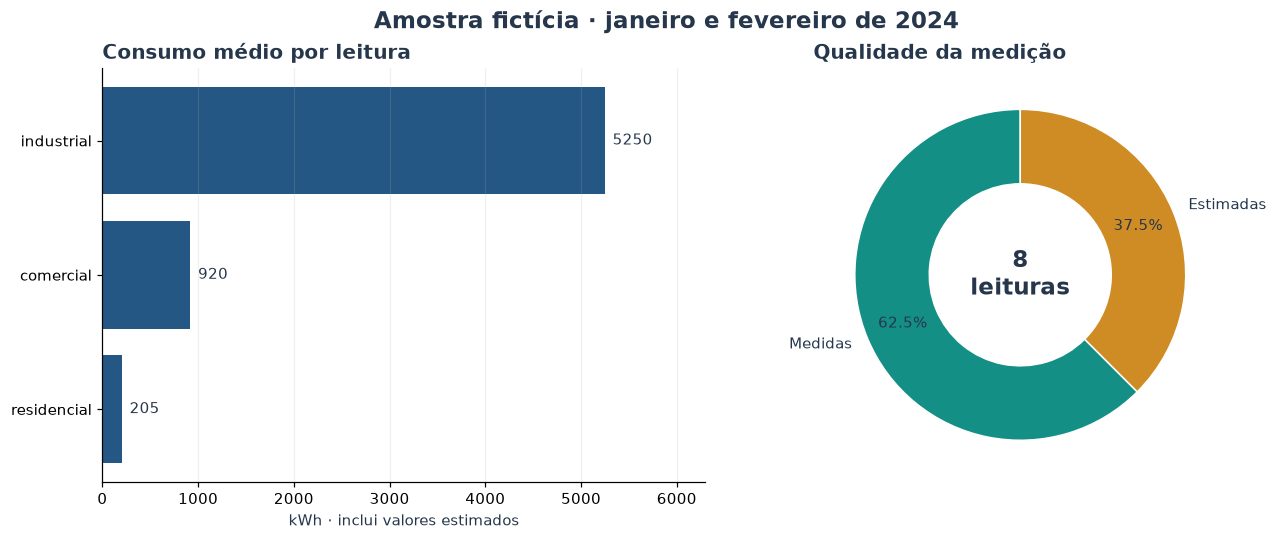

In [ ]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")

medias = consumo_por_tipo.sort_values("consumo_kwh")
barras = eixos[0].barh(medias["tipo_ligacao"], medias["consumo_kwh"], color=CORES["azul"])
eixos[0].bar_label(barras, fmt="%.0f", padding=5)
eixos[0].set_xlim(0, medias["consumo_kwh"].max() * 1.2)
eixos[0].set_title("Consumo médio por leitura", loc="left")
eixos[0].set_xlabel("kWh · inclui valores estimados")
eixos[0].grid(axis="x")

contagens = leituras["medicao_estimada"].value_counts().reindex([False, True], fill_value=0)
eixos[1].pie(
    contagens, labels=["Medidas", "Estimadas"], autopct="%.1f%%",
    colors=[CORES["verde"], CORES["ambar"]],
    startangle=90, wedgeprops={"width": 0.45, "edgecolor": "white"},
    pctdistance=0.77,
)
eixos[1].text(0, 0, f"{len(leituras)}\nleituras", ha="center", va="center",
              fontsize=15, weight="bold")
eixos[1].set_title("Qualidade da medição", loc="left")
fig.suptitle("Amostra fictícia · janeiro e fevereiro de 2024", fontsize=15, weight="bold")
plt.show()

### 4.2 · Conferir a qualidade dos dados

Uma tabela sem valores nulos ainda pode conter dados estimados ou poucos registros. Compare a quantidade de leituras disponíveis para cada cliente.

cliente_id,total_leituras,leituras_estimadas,leituras_medidas,proporcao_estimada
1001,2,1,1,50%
1002,2,0,2,0%
1003,2,1,1,50%
1004,1,0,1,0%
1005,1,1,0,100%


coluna,valores_nulos
cliente_id,0
mes,0
consumo_kwh,0
medicao_estimada,0


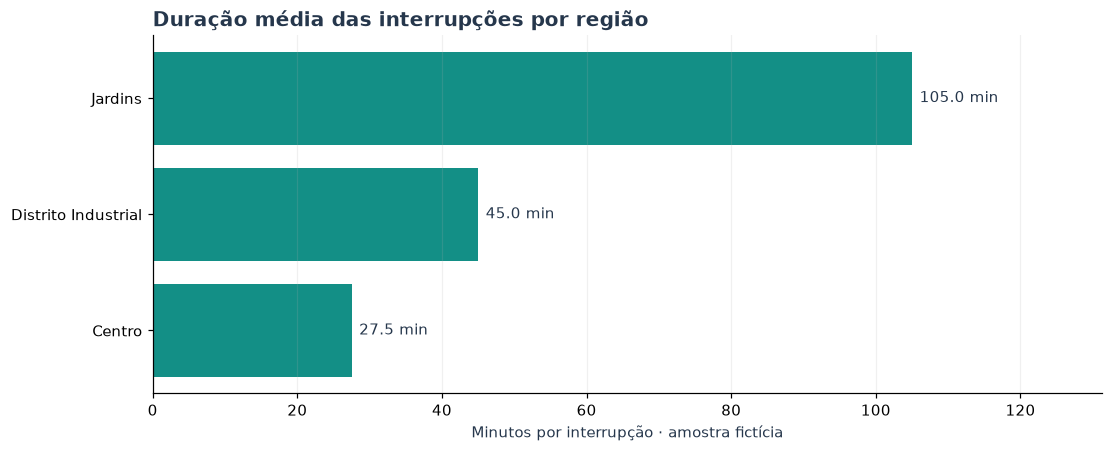

In [ ]:
auditoria = (
    leituras.groupby("cliente_id", as_index=False)
    .agg(total_leituras=("consumo_kwh", "size"),
         leituras_estimadas=("medicao_estimada", "sum"))
)
auditoria["leituras_medidas"] = auditoria["total_leituras"] - auditoria["leituras_estimadas"]
auditoria["proporcao_estimada"] = auditoria["leituras_estimadas"] / auditoria["total_leituras"]
mostrar_tabela(auditoria, "Cobertura e origem das leituras",
               {"proporcao_estimada": "{:.0%}"})

faltantes = leituras.isna().sum().rename_axis("coluna").reset_index(name="valores_nulos")
mostrar_tabela(faltantes, "Valores ausentes nas leituras")

resumo_ordenado = resumo_interrupcoes.sort_values("duracao_media_minutos")
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
barras = ax.barh(resumo_ordenado["regiao"], resumo_ordenado["duracao_media_minutos"],
                color=CORES["verde"])
ax.bar_label(barras, fmt="%.1f min", padding=5)
ax.set_xlim(0, resumo_ordenado["duracao_media_minutos"].max() * 1.25)
ax.set_title("Duração média das interrupções por região", loc="left")
ax.set_xlabel("Minutos por interrupção · amostra fictícia")
ax.grid(axis="x")
plt.show()

### Suas observações

**O que chamou a atenção nas tabelas ou nos gráficos?**

[Digite aqui.]

**Como as leituras estimadas e a quantidade de registros podem afetar a análise?**

[Digite aqui.]

**Os dados das inspeções seriam suficientes para tirar conclusões sobre todos os clientes? Por quê?**

[Digite aqui.]

In [ ]:
# SUA ANÁLISE: escreva e execute seu código aqui.
# Tabelas disponíveis: clientes, leituras, interrupcoes, inspecoes, chamados.
# Exemplo de consulta: leituras.loc[~leituras["medicao_estimada"]]

## 5 · Respostas do grupo

Quais problemas podem ser resolvidos com aprendizado de máquina neste cenário?

Para cada problema, registre:

- o tipo do problema;
- o que o modelo devolveria;
- quais dados alimentariam o modelo.

Preencha no mínimo duas respostas: uma de aprendizado supervisionado e outra de aprendizado não supervisionado.

### Resposta 1 — problema supervisionado

### Problema ou pergunta

[Digite aqui o problema que o modelo deve resolver.]

### Tipo

- [ ] Supervisionado
- [ ] Não supervisionado

**Tarefa de aprendizado** (por exemplo: classificação ou regressão):  
[Digite aqui.]

### O que o modelo devolveria

[Descreva a saída do modelo: uma categoria, um número, uma probabilidade etc.]

### Quais dados alimentariam o modelo

[Liste apenas os dados disponíveis que seriam usados como entrada e, se houver, indique a variável-alvo.]

### Justificativa

[Explique brevemente por que esse tipo de aprendizado é adequado ao problema.]

In [ ]:
# Código de apoio à resposta 1 (opcional).
# Escreva aqui suas consultas, gráficos ou modelo.
# As explicações devem ser preenchidas na célula de texto acima.

### Resposta 2 — problema não supervisionado

### Problema ou pergunta

[Digite aqui o problema que o modelo deve resolver.]

### Tipo

- [ ] Supervisionado
- [ ] Não supervisionado

**Tarefa de aprendizado** (por exemplo: agrupamento ou detecção de anomalias):  
[Digite aqui.]

### O que o modelo devolveria

[Descreva a saída do modelo: grupos de clientes, casos atípicos, padrões etc.]

### Quais dados alimentariam o modelo

[Liste os dados disponíveis que seriam usados como entrada.]

### Justificativa

[Explique brevemente por que esse tipo de aprendizado é adequado ao problema.]

In [ ]:
# Código de apoio à resposta 2 (opcional).
# Escreva aqui suas consultas, gráficos ou modelo.
# As explicações devem ser preenchidas na célula de texto acima.

### Resposta adicional 1 — opcional

### Problema ou pergunta

[Digite aqui.]

### Tipo

- [ ] Supervisionado
- [ ] Não supervisionado

**Tarefa de aprendizado:** [Digite aqui.]  
**O que o modelo devolveria:** [Digite aqui.]  
**Quais dados alimentariam o modelo:** [Digite aqui.]  
**Justificativa:** [Digite aqui.]

In [ ]:
# Código de apoio à resposta adicional 1 (opcional).
# Escreva aqui suas consultas, gráficos ou modelo.
# As explicações devem ser preenchidas na célula de texto acima.

### Resposta adicional 2 — opcional

### Problema ou pergunta

[Digite aqui.]

### Tipo

- [ ] Supervisionado
- [ ] Não supervisionado

**Tarefa de aprendizado:** [Digite aqui.]  
**O que o modelo devolveria:** [Digite aqui.]  
**Quais dados alimentariam o modelo:** [Digite aqui.]  
**Justificativa:** [Digite aqui.]

In [ ]:
# Código de apoio à resposta adicional 2 (opcional).
# Escreva aqui suas consultas, gráficos ou modelo.
# As explicações devem ser preenchidas na célula de texto acima.

## 6 · Laboratório de modelos — exemplos para adaptar

As duas demonstrações abaixo mostram como executar um modelo. Você pode escolher outros problemas nas suas respostas.

> A amostra contém apenas 5 clientes. Estes exemplos ensinam a usar `fit` e `predict`; não demonstram desempenho em clientes novos. Para avaliar um modelo real, seriam necessários mais dados, separação entre treino e teste e cuidado com a ordem temporal.

### 6.1 · Supervisionado: estimar consumo a partir do tipo de ligação

O modelo recebe o **tipo de ligação** e aprende a estimar o **consumo mensal em kWh**. A saída é numérica: trata-se de regressão. Nesta demonstração, só as leituras medidas são usadas como alvo.

O exemplo utiliza uma árvore pequena e transforma as categorias em colunas numéricas. `cliente_id` identifica um registro e não entra como característica.

**Execute as duas próximas células e, depois, altere os tipos de ligação em `novos_casos` para experimentar.**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor

base_supervisionada = (
    leituras.loc[~leituras["medicao_estimada"]]
    .merge(clientes, on="cliente_id", validate="many_to_one")
)
X = base_supervisionada[["tipo_ligacao"]]
y = base_supervisionada["consumo_kwh"]

preparacao = ColumnTransformer([
    ("tipo", OneHotEncoder(handle_unknown="ignore"), ["tipo_ligacao"])
])
modelo_supervisionado = make_pipeline(
    preparacao,
    DecisionTreeRegressor(max_depth=2, random_state=42),
)
modelo_supervisionado.fit(X, y)

print(f"Treino ilustrativo: {len(X)} leituras medidas de "
      f"{base_supervisionada['cliente_id'].nunique()} clientes.")
print("Sem avaliação em dados de teste: a amostra é apenas didática.")

Treino ilustrativo: 5 leituras medidas de 4 clientes.
Sem avaliação em dados de teste: a amostra é apenas didática.


In [ ]:
# EDITE AQUI: use tipos de ligação presentes no cadastro.
novos_casos = pd.DataFrame({
    "tipo_ligacao": ["residencial", "comercial", "industrial"],
})

tipos_conhecidos = set(base_supervisionada["tipo_ligacao"])
if not novos_casos["tipo_ligacao"].isin(tipos_conhecidos).all():
    raise ValueError(f"Use um dos tipos disponíveis no treino: {sorted(tipos_conhecidos)}")

previsoes = novos_casos.copy()
previsoes["consumo_previsto_kwh"] = modelo_supervisionado.predict(novos_casos)
mostrar_tabela(previsoes, "Previsões ilustrativas · não validadas em clientes novos",
               {"consumo_previsto_kwh": "{:,.1f}"})

tipo_ligacao,consumo_previsto_kwh
residencial,195.0
comercial,"1,000.0"
industrial,"5,100.0"


### Interprete o exemplo supervisionado

**Quais são a entrada e o alvo do modelo?**

[Digite aqui.]

**O que mudou ao alterar o tipo de ligação?**

[Digite aqui.]

**O que falta para saber se o modelo funcionaria em novos clientes?**

[Digite aqui.]

### 6.2 · Não supervisionado: agrupar os perfis da amostra

Agora o modelo agrupa clientes pelo **consumo médio** e pela **proporção de leituras estimadas**, sem receber uma classe correta para cada cliente.

Os dados são padronizados para que kWh e proporções possam ser comparados. A proporção estimada descreve a qualidade da medição, portanto os grupos não devem ser interpretados apenas como hábitos de consumo.

**Experimente:** altere `NUMERO_GRUPOS` para 2 ou 3. Você também pode remover `proporcao_leituras_estimadas` da lista `COLUNAS_PERFIL` e comparar os resultados. Os números dos grupos são identificadores, não uma ordem de qualidade ou risco.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# EDITE AQUI:
NUMERO_GRUPOS = 2
COLUNAS_PERFIL = ["consumo_medio_kwh", "proporcao_leituras_estimadas"]

perfil_agrupamento = (
    leituras.groupby("cliente_id", as_index=False)
    .agg(consumo_medio_kwh=("consumo_kwh", "mean"),
         proporcao_leituras_estimadas=("medicao_estimada", "mean"))
)

if not COLUNAS_PERFIL or not set(COLUNAS_PERFIL).issubset(
    {"consumo_medio_kwh", "proporcao_leituras_estimadas"}
):
    raise ValueError("Selecione uma ou as duas características do perfil.")
if not isinstance(NUMERO_GRUPOS, int) or not 2 <= NUMERO_GRUPOS < len(perfil_agrupamento):
    raise ValueError("Escolha um número inteiro de grupos entre 2 e o número de clientes menos 1.")

modelo_agrupamento = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=NUMERO_GRUPOS, random_state=42, n_init=10),
)
perfil_agrupamento["grupo"] = (
    modelo_agrupamento.fit_predict(perfil_agrupamento[COLUNAS_PERFIL]) + 1
)

mostrar_tabela(perfil_agrupamento, "Grupos encontrados na amostra fictícia",
               {"consumo_medio_kwh": "{:,.1f}",
                "proporcao_leituras_estimadas": "{:.0%}"})

cliente_id,consumo_medio_kwh,proporcao_leituras_estimadas,grupo
1001,217.5,50%,2
1002,"1,000.0",0%,2
1003,"5,250.0",50%,1
1004,180.0,0%,2
1005,760.0,100%,2


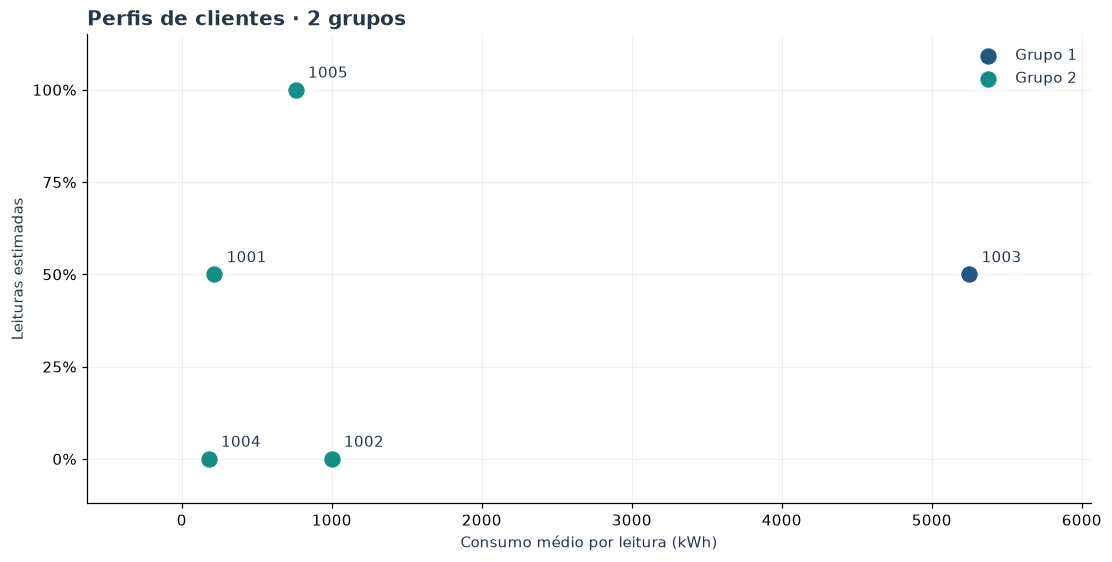

In [ ]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")
paleta = [CORES["azul"], CORES["verde"], CORES["ambar"], CORES["roxo"]]

for indice, (grupo, dados_grupo) in enumerate(perfil_agrupamento.groupby("grupo")):
    ax.scatter(dados_grupo["consumo_medio_kwh"], dados_grupo["proporcao_leituras_estimadas"],
               s=150, color=paleta[indice % len(paleta)], label=f"Grupo {grupo}",
               edgecolors="white", linewidths=1.5, zorder=3)

for linha in perfil_agrupamento.itertuples():
    ax.annotate(str(linha.cliente_id),
                (linha.consumo_medio_kwh, linha.proporcao_leituras_estimadas),
                xytext=(8, 8), textcoords="offset points", fontsize=10)

ax.set_title(f"Perfis de clientes · {NUMERO_GRUPOS} grupos", loc="left")
ax.set_xlabel("Consumo médio por leitura (kWh)")
ax.set_ylabel("Leituras estimadas")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylim(-0.12, 1.15)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.margins(x=0.16)
ax.grid()
ax.legend(frameon=False, loc="upper right")
plt.show()

### Interprete o agrupamento

**O que os clientes de cada grupo têm em comum?**

[Digite aqui.]

**Como os grupos mudaram ao alterar a quantidade de grupos ou as colunas utilizadas?**

[Digite aqui.]

**Qual é o efeito de incluir leituras estimadas no perfil de consumo?**

[Digite aqui.]

## 7 · Revisão e entrega

- [ ] A Resposta 1 é um problema supervisionado e possui uma variável-alvo identificável.
- [ ] A Resposta 2 é um problema não supervisionado e não depende de rótulos prontos.
- [ ] As saídas dos modelos estão descritas de forma concreta.
- [ ] Todos os dados citados existem na lista fornecida.
- [ ] As escolhas foram justificadas.

---

*Conteúdo transcrito e adaptado de `exercicio.jpeg` para preenchimento digital.*

- [ ] Executei as células de código que utilizei e conferi os resultados.
- [ ] Substituí os campos de resposta entre colchetes.
- [ ] Identifiquei os limites dos dados fictícios nas minhas conclusões.
- [ ] Salvei o notebook com as respostas e os resultados.

**Entrega:** este arquivo `exercicio.ipynb`, com as células de texto preenchidas. As demonstrações de código são apoio à atividade.

*Conversão do Markdown para notebook: dados originais preservados, tabelas e gráficos executáveis acrescentados e respostas mantidas em branco.*